# 04 · Anomaly layer

An Isolation Forest over behavioural features, trained **unsupervised**.

Why unsupervised, with labels available? Because a real bank has none. There is
no trustworthy transaction-level laundering label in production, only a backlog
of closed alerts, most marked no-further-action. A classifier trained on 139
labels would score brilliantly and model this generator rather than laundering.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "axes.edgecolor": "#e3e2dc", "grid.color": "#e3e2dc",
                     "axes.titleweight": "bold", "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False})
S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"

In [2]:
import ml_layer
df = pd.read_csv(config.CLEAN_TRANSACTIONS, parse_dates=["timestamp"])
X = ml_layer.build_features(df)
print(f"{X.shape[0]:,} rows x {X.shape[1]} features")
list(X.columns)

60,059 rows x 26 features


['log_amount',
 'amount_z_vs_account',
 'amount_vs_account_max',
 'hour',
 'is_night',
 'day_of_week',
 'is_weekend',
 'is_cross_border',
 'sender_velocity_24h',
 'sender_velocity_7d',
 'receiver_velocity_24h',
 'sender_txn_count',
 'sender_distinct_counterparties',
 'receiver_distinct_counterparties',
 'sender_account_age_days',
 'pct_of_threshold',
 'transaction_type_deposit',
 'transaction_type_payment',
 'transaction_type_transfer',
 'transaction_type_withdrawal',
 'channel_atm_withdrawal',
 'channel_card_payment',
 'channel_mobile_app',
 'channel_online_transfer',
 'channel_unknown',
 'channel_wire_transfer']

## Two deliberate exclusions

**No identifier features.** The ID encodes the answer, as notebook 01 showed.

**No high-risk-country feature**, even though adding it would raise the model's
standalone score. That signal already has a rule. Keeping it out means the two
layers fail independently, and independence is the only reason corroborating one
against the other adds information.

## No lookahead

Every account statistic uses only that account's history *before* each
transaction. Computing them over the full twelve months would score a January
transaction partly on the following December's behaviour, which no production
system has at decision time.

Expanding statistics are shifted by one row, so a transaction never contributes
to its own baseline.

In [3]:
acct = df.sender_account.value_counts().index[0]
rows = df[df.sender_account == acct].sort_values("timestamp").head(8)
pd.DataFrame({
    "amount": rows.amount.values,
    "z_vs_prior_history": X.loc[rows.index, "amount_z_vs_account"].values.round(3),
    "txns_seen_before": X.loc[rows.index, "sender_txn_count"].values.astype(int),
})

,amount,z_vs_prior_history,txns_seen_before
0,135.10,0.000,0
1,133.38,0.000,1
2,267.50,0.000,2
3,133.50,0.000,3
4,198.87,0.000,4
5,190.70,0.286,5
6,240.11,1.185,6
7,35.05,-2.758,7


The first transactions score 0 on the z-score: with no history there is nothing
to be unusual against. The count starts at zero and grows. That is the shape
correct trailing features should have.

The z-score also requires 5 prior transactions before it is trusted, because
with 2 the expanding standard deviation approaches zero and the score explodes
into the thousands.

## Fitting

In [4]:
scores, model, _ = ml_layer.fit_score(df)
print(scores.anomaly_score.describe().round(4).to_string())

count    60059.0000
mean         0.4522
std          0.0321
min          0.3968
25%          0.4286
50%          0.4458
75%          0.4692
max          0.7104


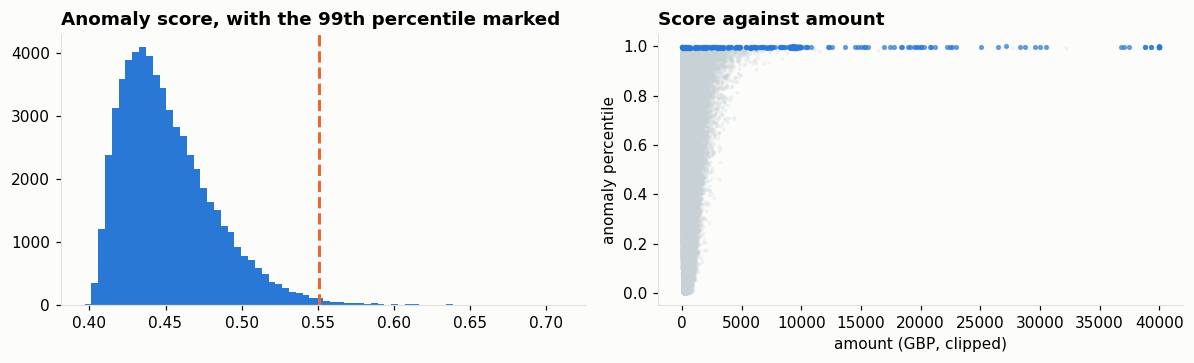

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(scores.anomaly_score, bins=70, color=S1)
axes[0].axvline(scores.anomaly_score.quantile(.99), color=S2, ls="--", lw=2)
axes[0].set_title("Anomaly score, with the 99th percentile marked", loc="left")

top = df.assign(pct=scores.anomaly_pct).nlargest(300, "pct")
axes[1].scatter(df.amount.clip(upper=40000), scores.anomaly_pct, s=3, alpha=.15, color="#c8d2d6")
axes[1].scatter(top.amount.clip(upper=40000), top.pct, s=6, alpha=.6, color=S1)
axes[1].set_xlabel("amount (GBP, clipped)"); axes[1].set_ylabel("anomaly percentile")
axes[1].set_title("Score against amount", loc="left")
plt.tight_layout(); plt.show()

The model is not simply ranking by size: plenty of small transactions score
high, and plenty of large ones do not. It is keying on the combination of amount
shape, timing, velocity and counterparty spread.

## What the model alone achieves

Measured properly in notebook 05, but the shape is worth seeing here: the model
is a good ranker and an incomplete detector.

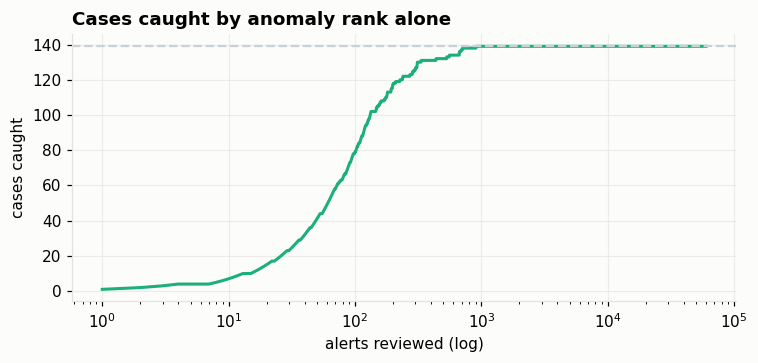

all 139 cases require the top 909 alerts


In [6]:
truth = (pd.read_csv(config.GROUND_TRUTH).drop_duplicates("transaction_id")
           .set_index("transaction_id")["is_laundering_pattern"])
y = df.transaction_id.map(truth).fillna(0).astype(int)
ranked = y.iloc[np.argsort(-scores.anomaly_score.values)].cumsum().values

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(range(1, len(ranked) + 1), ranked, color=S3, lw=2)
ax.set_xscale("log"); ax.set_xlabel("alerts reviewed (log)"); ax.set_ylabel("cases caught")
ax.axhline(int(y.sum()), color="#c8d2d6", ls="--")
ax.set_title("Cases caught by anomaly rank alone", loc="left")
ax.grid(alpha=.6); plt.tight_layout(); plt.show()
print(f"all {int(y.sum())} cases require the top {int(np.argmax(ranked == y.sum())) + 1:,} alerts")